<a href="https://colab.research.google.com/github/nJuleigh/TIL/blob/main/NICE%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# =========================================================
# 0. 실행환경 확인
# =========================================================


#pip install pandas numpy scipy scikit-learn lightgbm matplotlib shap ucimlrepo
#pip install optbinning
#pip install scorecardpy

import sys
import importlib
import pandas as pd
import numpy as np
import scipy
import sklearn
import matplotlib.pyplot as plt

print("python", sys.version.split()[0])
print(
    "pandas", pd.__version__,
    "| numpy", np.__version__,
    "| scipy", scipy.__version__,
    "| sklearn", sklearn.__version__
)

for lib in [
    "lightgbm",
    "shap",
    "optbinning",
    "scorecardpy",
    "ucimlrepo"
]:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, "__version__", "")
        print(f"{lib:12s} OK  {version}")
    except ImportError:
        print(f"{lib:12s} 없음")

python 3.13.15
pandas 2.2.3 | numpy 2.1.3 | scipy 1.16.3 | sklearn 1.6.1
lightgbm     OK  4.6.0
shap         OK  0.52.0
optbinning   OK  1.0.0
scorecardpy  없음
ucimlrepo    OK  


In [18]:
!pip install ucimlrepo
print("complete")

complete


In [19]:

# =========================================================
# 1. UCI 데이터 불러오기
# =========================================================


from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=365) # UCI의 365번 데이터

print(ds.variables[["name", "role", "type"]]) # year, A_i : Feature/class:Target
print("데이터 다운로드 완료")
print("전체 데이터 크기:", ds.data.original.shape)
print(ds.data.original.head())

data = ds.data.original.copy() # 원본 복사본

feature_cols = [f"A{i}" for i in range(1, 65)]
print(feature_cols)

X=data[feature_cols].copy() # 변수 64개 열만 X에 저장
y=data["class"].copy() # 부도 여부(target)

print("전체 데이터:", data.shape)
print("입력변수 X:", X.shape)
print("타깃 y:", y.shape)
print(X.head())
print(X.dtypes.value_counts())


     name     role        type
0    year  Feature     Integer
1      A1  Feature  Continuous
2      A2  Feature  Continuous
3      A3  Feature  Continuous
4      A4  Feature  Continuous
..    ...      ...         ...
61    A61  Feature  Continuous
62    A62  Feature  Continuous
63    A63  Feature  Continuous
64    A64  Feature  Continuous
65  class   Target     Integer

[66 rows x 3 columns]
데이터 다운로드 완료
전체 데이터 크기: (43405, 66)
   year        A1       A2       A3      A4       A5       A6        A7  \
0     1  0.200550  0.37951  0.39641  2.0472  32.3510  0.38825  0.249760   
1     1  0.209120  0.49988  0.47225  1.9447  14.7860  0.00000  0.258340   
2     1  0.248660  0.69592  0.26713  1.5548  -1.1523  0.00000  0.309060   
3     1  0.081483  0.30734  0.45879  2.4928  51.9520  0.14988  0.092704   
4     1  0.187320  0.61323  0.22960  1.4063  -7.3128  0.18732  0.187320   

        A8      A9  ...       A56      A57      A58       A59     A60     A61  \
0  1.33050  1.1389  ...  0.121960  0.3

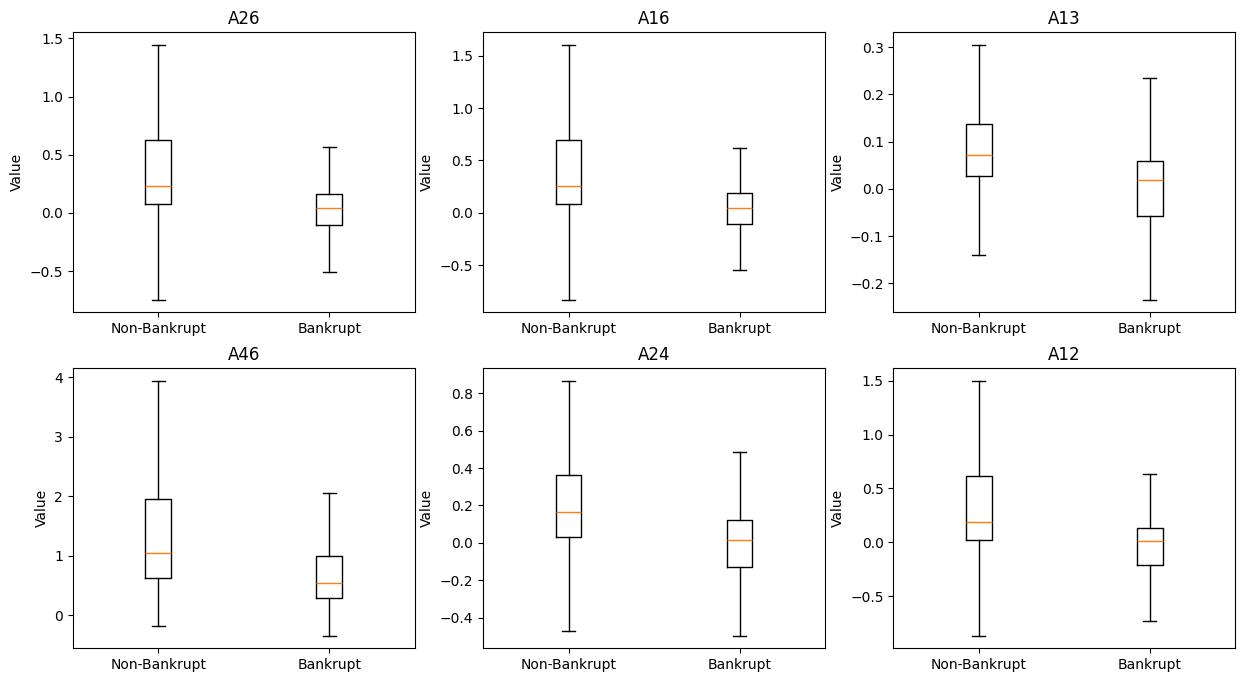

In [20]:

# 3. year별 표본 수와 부도율 확인

summary = (
    data.groupby("year")["class"]
    .agg(
        n="size", #전체 기업 수
        bad="sum" #부도 기업 수
    )
)

summary["bad_rate"]=(
    summary["bad"] / summary["n"]
).round(4)


summary.loc["total"] = [
    len(data),
    data["class"].sum(),
    round(data["class"].mean(), 4)
]

# print(summary)

# 결측값 확인

missing_rate =(
    X.isna()
    .mean() #결측률
    .sort_values(ascending=False)
)

# print("결측값이 있는 변수 수:", (missing_rate >0).sum())
# print("\n결측률 상위 10개 변수:")
# print(missing_rate.head(10))


missing_by_year=(
    data.groupby("year")[feature_cols]
    .apply(lambda group: group.isna().mean().mean()) #각 변수의 결측률들의 평균의 평균>변수 전체에 대한 평균 결측률
)

# print("\n연도별 평균 결측률:")
# print(missing_by_year)


#중복행 확인

duplicate_cnt = data.duplicated(
    subset = feature_cols
).sum()

# print("재무변수 기준 추가 중복행 수:", duplicate_cnt)


# 변수의 분포와 극단값 확인
desc = X.describe(
    percentiles = [0.01, 0.5, 0.99]
).T

desc["abs_max"] = X.abs().max()

# print(
#     desc[
#         ["count", "1%", "50%", "99%", "abs_max"]
#     ]
#     .sort_values("abs_max", ascending = False)
#     .head(10)
# )


# 무한대와 상수 변수 확인

inf_cnt = np.isinf(X).sum()

# print("무한대가 있는 변수 수 :", (inf_cnt>0).sum())
# print(inf_cnt[inf_cnt>0])

constant_cols=[
    col for col in feature_cols
    if data[col].nunique(dropna=True)<=1
]

# print("상수 변수:", constant_cols)

###### 무한대, 상수 변수 모두 없음.

#클래스 불균형 확인

class_summary=(
    data["class"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

class_summary["rate"]=(
    class_summary["count"] / len(data)
).round(4)

# print(class_summary)

# class_summary["count"].plot(
#     kind = "bar",
#     color = ["steelblue", 'tomato']
# )
#
# plt.title("Class Distribution")
# plt.xlabel("Class (0: Non-bankrupt, 1: Bankrupt)")
# plt.ylabel("Number of Companies")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()


###### 전체 43405개의 기업 중 부도 기업은 2091개, 정상기업은 41314개. (부도율 4.82%)
###### 클래스 불균형 존재 > 모델은 Recall, Precision, F1-score, ROC-AUC, PR-AUC 함께 평가


# 부도 여부와 관련성이 큰 변수 확인


target_corr = X.corrwith( #각 재무변수와 부도 여부 사이의 Spearman 상관계수
    data["class"],
    method="spearman"
)

target_corr_table = pd.DataFrame(
    {
        "correlation": target_corr,
        "abs_correlation": target_corr.abs()
    }
)

target_corr_table = target_corr_table.sort_values(
    "abs_correlation",
    ascending=False
)

# print(target_corr_table.head(10))


############################################################
###### 재무변수에 극단값 존재하므로 실제 값 자체보다 값의 순위를 이용
###### A26이 -0.165로 가장 큰 상관관계 보임.
###### 상위 10개가 모두 음수> 값이 클수록 보두 가능성이 낮아지는 방향
###### 말할 수 없음> 가장 큰 절댓값도 0에 가까우므로 변수 하나만으로 부도 구분 어려움
############################################################


# 변수 분포와 변수 간 높은 상관관계 확인


    # 정상기업과 부도기업의 변수 분포 비교
top_features=(
    target_corr_table
    .head(6)
    .index
    .tolist()
)

# print(top_features)

fig, axes =plt.subplots(
    2, 3,
    figsize=(15,8)
)

axes = axes.flatten()

for ax, col in zip(axes, top_features):
    normal = data.loc[
        data["class"] == 0, col
    ].dropna()

    bankrupt = data.loc[
        data["class"] == 1, col
    ].dropna()

    ax.boxplot(
        [normal, bankrupt],
        tick_labels=["Non-Bankrupt", "Bankrupt"],
        showfliers=False
    )

    ax.set_title(col)
    ax.set_ylabel("Value")

# plt.suptitle(
#     "정상기업과 부도기업의 변수 분포 비교"
# )
#
# plt.tight_layout()
# plt.show()

    # 변수끼리 높은 상관관계가 있는지 확인

corr_matrix = X.corr(
    method="spearman"
)

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs=(
    upper_triangle
    .stack()
    .reset_index()
)

corr_pairs.columns =[
    "featrue_1",
    "featrue_2",
    "correlation"
]

corr_pairs["abs_correlation"]=(
    corr_pairs["correlation"].abs()
)


high_corr_pairs = (
    corr_pairs[
        corr_pairs["abs_correlation"]>=0.9
    ]
    .sort_values(
        "abs_correlation",
        ascending=False
    )
)

# print(high_corr_pairs)
# print("높은 상관관계를 가진 변수 쌍 개수:", len(high_corr_pairs))

############################################################
###### 상위 변수의 분포가 정상/부도기업 사이에서 실제로 다른지?
# A1-A64 중 서로 거의 같은 움짐임을 보이는 변수 쌍이 있는지?
###### 상위 6개 변수 : 중앙값(정상>부도), 정상과 부도 사이에 분포의 위치와 사분위 범위도 차이
###### 해당 변수들이 부도 여부와 Spearman 상관 계수 실험 결과가 유지됨을 확인.
######그러나 개별 변수 하나만으로 부도 여부 명확히 구분 어려움.


In [21]:

# =========================================================
# 2. Modeling sample: one-year bankruptcy prediction
# =========================================================

from sklearn.model_selection import train_test_split

# year=5:
# 재무제표 관측 후 1년 이내 부도 여부를 예측하는 표본
model_data = data.loc[
    data["year"] == 5,
    feature_cols + ["class"]
].copy()

X_model = model_data[feature_cols].copy()
y_model = model_data["class"].copy()

# print("모델링 표본 크기:", model_data.shape)
# print("\n부도 여부:")
# print(y_model.value_counts().sort_index())
# print("\n부도율:")
# print(y_model.value_counts(normalize=True).sort_index())

# 전체의 60%는 훈련, 40%는 임시 표본
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.40,
    stratify=y_model,
    random_state=42
)

# 임시 표본을 검증 20%, 테스트 20%로 분할
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

split_summary = pd.DataFrame({
    "sample": ["train", "validation", "test"],
    "n": [
        len(y_train),
        len(y_valid),
        len(y_test)
    ],
    "bad": [
        y_train.sum(),
        y_valid.sum(),
        y_test.sum()
    ],
    "bad_rate": [
        y_train.mean(),
        y_valid.mean(),
        y_test.mean()
    ]
})

# print(split_summary)


In [22]:
# =========================================================
# 3. Missing values in training data
# =========================================================

train_missing_rate = (
    X_train
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("훈련 데이터 결측률 상위 10개 변수:")
print(train_missing_rate.head(10))

missing_threshold = 0.30

high_missing_cols = train_missing_rate[
    train_missing_rate >= missing_threshold
].index.tolist()

candidate_cols = [
    col for col in feature_cols
    if col not in high_missing_cols
]

print("\n결측률 30% 이상 변수:", high_missing_cols)
print("제외 후 후보 변수 수:", len(candidate_cols))

훈련 데이터 결측률 상위 10개 변수:
A37    0.432036
A27    0.060068
A45    0.042583
A60    0.042583
A24    0.021715
A54    0.018613
A28    0.018613
A53    0.018613
A64    0.018613
A21    0.016638
dtype: float64

결측률 30% 이상 변수: ['A37']
제외 후 후보 변수 수: 63


In [16]:
# =========================================================
# 4. Optimal binning, WOE and IV
# =========================================================
!pip install optbinning

from optbinning import OptimalBinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.4/234.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 21.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21

(CVXPY) Sep 17 02:29:03 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/usr/local/lib/python3.13/dist-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')
(CVXPY) Sep 17 02:29:03 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Sep 17 02:29:03 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Sep 17 02:29:03 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/usr/local/lib/python3.13/dist-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


In [23]:
binning_models = {}
iv_results = []
failed_binning_cols = {}

for i, col in enumerate(candidate_cols, start=1):
    try:
        binning_model = OptimalBinning(
            name=col,
            dtype="numerical",
            monotonic_trend="auto",
            max_n_prebins=20,
            max_n_bins=6,
            min_bin_size=0.05,
            time_limit=20
        )

        binning_model.fit(
            X_train[col].to_numpy(),
            y_train.to_numpy()
        )

        # IV 계산을 위해 구간화 표 생성
        binning_model.binning_table.build()

        binning_models[col] = binning_model

        iv_results.append({
            "feature": col,
            "iv": binning_model.binning_table.iv,
            "status": binning_model.status,
            "n_bins": len(binning_model.splits) + 1
        })

        print(
            f"{i:02d}/{len(candidate_cols)} "
            f"{col}: 완료"
        )

    except Exception as error:
        failed_binning_cols[col] = str(error)

        print(
            f"{i:02d}/{len(candidate_cols)} "
            f"{col}: 실패 - {error}"
        )

01/63 A1: 완료
02/63 A2: 완료
03/63 A3: 완료
04/63 A4: 완료
05/63 A5: 완료
06/63 A6: 완료
07/63 A7: 완료
08/63 A8: 완료
09/63 A9: 완료
10/63 A10: 완료
11/63 A11: 완료
12/63 A12: 완료
13/63 A13: 완료
14/63 A14: 완료
15/63 A15: 완료
16/63 A16: 완료
17/63 A17: 완료
18/63 A18: 완료
19/63 A19: 완료
20/63 A20: 완료
21/63 A21: 완료
22/63 A22: 완료
23/63 A23: 완료
24/63 A24: 완료
25/63 A25: 완료
26/63 A26: 완료
27/63 A27: 완료
28/63 A28: 완료
29/63 A29: 완료
30/63 A30: 완료
31/63 A31: 완료
32/63 A32: 완료
33/63 A33: 완료
34/63 A34: 완료
35/63 A35: 완료
36/63 A36: 완료
37/63 A38: 완료
38/63 A39: 완료
39/63 A40: 완료
40/63 A41: 완료
41/63 A42: 완료
42/63 A43: 완료
43/63 A44: 완료
44/63 A45: 완료
45/63 A46: 완료
46/63 A47: 완료
47/63 A48: 완료
48/63 A49: 완료
49/63 A50: 완료
50/63 A51: 완료
51/63 A52: 완료
52/63 A53: 완료
53/63 A54: 완료
54/63 A55: 완료
55/63 A56: 완료
56/63 A57: 완료
57/63 A58: 완료
58/63 A59: 완료
59/63 A60: 완료
60/63 A61: 완료
61/63 A62: 완료
62/63 A63: 완료
63/63 A64: 완료


In [24]:
iv_table = (
    pd.DataFrame(iv_results)
    .sort_values("iv", ascending=False)
    .reset_index(drop=True)
)

print("\nIV 상위 15개 변수:")
print(iv_table.head(15))

print("\n구간화 실패 변수 수:", len(failed_binning_cols))
print("구간화 실패 변수:", failed_binning_cols)


IV 상위 15개 변수:
   feature        iv   status  n_bins
0      A21  2.290498  OPTIMAL       6
1      A27  2.112552  OPTIMAL       6
2      A41  1.388874  OPTIMAL       6
3      A35  1.378269  OPTIMAL       6
4      A22  1.367202  OPTIMAL       6
5      A39  1.365776  OPTIMAL       4
6      A42  1.337677  OPTIMAL       6
7      A13  1.309879  OPTIMAL       6
8      A19  1.292061  OPTIMAL       6
9      A12  1.286001  OPTIMAL       6
10     A15  1.282628  OPTIMAL       6
11     A26  1.273626  OPTIMAL       6
12     A16  1.262362  OPTIMAL       6
13     A11  1.213260  OPTIMAL       6
14     A45  1.212172  OPTIMAL       6

구간화 실패 변수 수: 0
구간화 실패 변수: {}


monotonic_trend="auto" > 변수값이 변할 때 부도위험이 가능한 한 일관된 방향으로 움직이는 구간화를 자동으로 탐색

max_n_bins=6 > 구간을 지나치게 잘게 나눠 훈련 데이터에만 맞추는 것을 막고, 사람이 해석할 수 있는 수준으로 제한

min_bin_size=0.05 > 하나의 구간이 훈련 표본의 최소 5% 이상을 포함하도록 합니다. 표본이 너무 작은 구간에서 우연히 높은 부도율이 나오는 것을 줄이기 위한 설정

time_limit=20 > 한 변수를 최적화하는 데 최대 20초만 사용해 전체 실행시간을 제한

구간화는 정상적으로 완료
IV가 1을 넘는 변수가 매우 많음
그러나 "예측력이 매우 강하다"고 섣부르게 판단하기 어려움.
(과적합 가능성 있음)

> 단순히 IV 상위 변수를 고르지 않고, 검증 데이터에서도 각 변수의 구분력이 유지되는지 확인

현재 단계에서는 IV가 높다는 이유만으로 바로 변수를 선택하지 않습니다. 결과를 본 다음:
- IV가 너무 낮은 변수
- 비정상적으로 IV가 높은 변수
- 서로 강하게 중복되는 변수
- WOE 방향이 해석하기 어려운 변수
를 함께 검토해 최종 후보를 정합니다.

In [25]:
# =========================================================
# 5. Univariate validation of WOE variables
# =========================================================

from sklearn.metrics import roc_auc_score

woe_validation_results = []

for col in iv_table["feature"]:
    binning_model = binning_models[col]

    train_woe = binning_model.transform(
        X_train[col].to_numpy(),
        metric="woe"
    )

    valid_woe = binning_model.transform(
        X_valid[col].to_numpy(),
        metric="woe"
    )

    train_auc_raw = roc_auc_score(
        y_train,
        train_woe
    )

    valid_auc_raw = roc_auc_score(
        y_valid,
        valid_woe
    )

    # WOE 부호 방향과 관계없이 구분력의 크기를 0.5~1로 표시
    train_auc = max(
        train_auc_raw,
        1 - train_auc_raw
    )

    valid_auc = max(
        valid_auc_raw,
        1 - valid_auc_raw
    )

    same_direction = (
        (train_auc_raw - 0.5) *
        (valid_auc_raw - 0.5)
        >= 0
    )

    woe_validation_results.append({
        "feature": col,
        "train_auc": train_auc,
        "valid_auc": valid_auc,
        "auc_gap": train_auc - valid_auc,
        "same_direction": same_direction
    })

In [26]:
#IV결과와 합침

feature_screening = (
    iv_table
    .merge(
        pd.DataFrame(woe_validation_results),
        on="feature",
        how="left"
    )
    .sort_values(
        "valid_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    feature_screening[
        [
            "feature",
            "iv",
            "train_auc",
            "valid_auc",
            "auc_gap",
            "same_direction",
            "n_bins"
        ]
    ].head(15)
)

   feature        iv  train_auc  valid_auc   auc_gap  same_direction  n_bins
0      A27  2.112552   0.842968   0.825948  0.017020            True       6
1      A39  1.365776   0.779842   0.797206 -0.017364            True       4
2      A35  1.378269   0.774033   0.784396 -0.010363            True       6
3      A16  1.262362   0.784403   0.779396  0.005007            True       6
4      A46  0.954729   0.740129   0.778076 -0.037947            True       6
5      A26  1.273626   0.786560   0.777838  0.008722            True       6
6      A41  1.388874   0.788733   0.775654  0.013079            True       6
7      A42  1.337677   0.774770   0.774396  0.000374            True       6
8      A15  1.282628   0.783656   0.771846  0.011810            True       6
9      A45  1.212172   0.780927   0.770721  0.010206            True       6
10     A13  1.309879   0.784063   0.768304  0.015759            True       6
11     A12  1.286001   0.786756   0.766813  0.019943            True       6

훈련 표본의 IV만으로 변수를 선정하면 최적 구간화에 따른 과적합 가능성이 있다고 판단

따라서 훈련 표본에서 결정한 구간과 WOE를 고정한 뒤 검증 표본에 적용하여 단변량 AUC와 관계 방향의 재현성을 추가로 확인

중요한 점은 훈련 데이터에서만 높았던 결과가 검증 데이터에서도 상당히 유지됐다는 것입니다.
- A27: 검증 AUC 약 0.826으로 가장 높음
- 상위 15개 모두 same_direction=True
- 대부분 훈련·검증 AUC 차이가 0.02 안팎
- 음수 auc_gap은 검증 AUC가 훈련 AUC보다 조금 높았다는 뜻이며 문제는 아님
- IV 1위였던 A21은 검증 AUC 상위 15개에는 없음

특히 A21 사례는 “IV만으로 선택하지 않고 검증 재현성을 확인한 이유”를 보여주는 좋은 결과

In [27]:
#서로 비슷한 정보를 담는 변수를 정리

print(
    feature_screening[
        [
            "feature",
            "iv",
            "train_auc",
            "valid_auc",
            "auc_gap",
            "same_direction",
            "n_bins"
        ]
    ].head(15)
)

   feature        iv  train_auc  valid_auc   auc_gap  same_direction  n_bins
0      A27  2.112552   0.842968   0.825948  0.017020            True       6
1      A39  1.365776   0.779842   0.797206 -0.017364            True       4
2      A35  1.378269   0.774033   0.784396 -0.010363            True       6
3      A16  1.262362   0.784403   0.779396  0.005007            True       6
4      A46  0.954729   0.740129   0.778076 -0.037947            True       6
5      A26  1.273626   0.786560   0.777838  0.008722            True       6
6      A41  1.388874   0.788733   0.775654  0.013079            True       6
7      A42  1.337677   0.774770   0.774396  0.000374            True       6
8      A15  1.282628   0.783656   0.771846  0.011810            True       6
9      A45  1.212172   0.780927   0.770721  0.010206            True       6
10     A13  1.309879   0.784063   0.768304  0.015759            True       6
11     A12  1.286001   0.786756   0.766813  0.019943            True       6

In [28]:
# =========================================================
# 6. Feature screening and redundancy reduction
# =========================================================

screening_mask = (
    (feature_screening["iv"] >= 0.10)
    & (feature_screening["valid_auc"] >= 0.65)
    & (feature_screening["auc_gap"].abs() <= 0.05)
    & (feature_screening["same_direction"])
)

screened_table = (
    feature_screening[screening_mask]
    .sort_values(
        ["valid_auc", "iv"],
        ascending=False
    )
    .reset_index(drop=True)
)

screened_features = screened_table[
    "feature"
].tolist()

print("검증 안정성 기준 통과 변수 수:", len(screened_features))

print(
    screened_table[
        [
            "feature",
            "iv",
            "train_auc",
            "valid_auc",
            "auc_gap"
        ]
    ]
)

검증 안정성 기준 통과 변수 수: 50
   feature        iv  train_auc  valid_auc   auc_gap
0      A27  2.112552   0.842968   0.825948  0.017020
1      A39  1.365776   0.779842   0.797206 -0.017364
2      A35  1.378269   0.774033   0.784396 -0.010363
3      A16  1.262362   0.784403   0.779396  0.005007
4      A46  0.954729   0.740129   0.778076 -0.037947
5      A26  1.273626   0.786560   0.777838  0.008722
6      A41  1.388874   0.788733   0.775654  0.013079
7      A42  1.337677   0.774770   0.774396  0.000374
8      A15  1.282628   0.783656   0.771846  0.011810
9      A45  1.212172   0.780927   0.770721  0.010206
10     A13  1.309879   0.784063   0.768304  0.015759
11     A12  1.286001   0.786756   0.766813  0.019943
12     A23  1.210030   0.770761   0.765998  0.004763
13      A1  1.174667   0.763048   0.765870 -0.002823
14     A25  1.031446   0.762610   0.761053  0.001556
15     A24  1.014742   0.763010   0.756125  0.006885
16     A56  0.822537   0.720391   0.756120 -0.035729
17     A22  1.367202   0

현재 기준은 다음과 같습니다.
- IV 0.10 이상
- 검증 AUC 0.65 이상
- 훈련·검증 AUC 차이 절댓값 0.05 이하
- 관계 방향이 훈련·검증에서 동일

이는 보편적인 절대 기준이 아니라 이번 프로젝트에서 변수 수를 제한하고 재현성이 낮은 변수를 거르기 위한 사전 기준

In [29]:
# 통과 변수들을 WOE로 변환

X_train_woe_screened = pd.DataFrame(
    index=X_train.index
)

for col in screened_features:
    X_train_woe_screened[col] = (
        binning_models[col].transform(
            X_train[col].to_numpy(),
            metric="woe"
        )
    )

In [30]:
# WOE 변수 간 상관계수 계산

woe_corr = X_train_woe_screened.corr(
    method="pearson"
)

In [31]:
# 중복 변수를 순차적으로 제거:
# 검증 AUC가 높은 변수부터 검토하고, 이미 선택된 변수와 절댓값 0.70 이상의 상관관계를 가지면 제외

correlation_threshold = 0.70
max_features = 10

selected_features = []
redundancy_log = []

for col in screened_features:
    if not selected_features:
        selected_features.append(col)
        continue

    correlations = (
        woe_corr
        .loc[col, selected_features]
        .abs()
    )

    max_corr = correlations.max()
    most_related_feature = correlations.idxmax()

    if max_corr >= correlation_threshold:
        redundancy_log.append({
            "excluded_feature": col,
            "kept_feature": most_related_feature,
            "abs_correlation": max_corr
        })
    else:
        selected_features.append(col)

    if len(selected_features) >= max_features:
        break

In [32]:
# 결과 출력

redundancy_table = pd.DataFrame(
    redundancy_log
)

print("선택된 변수:", selected_features)
print("선택된 변수 수:", len(selected_features))

print("\n높은 WOE 상관관계로 제외된 변수:")
print(redundancy_table)

선택된 변수: ['A27', 'A39', 'A16', 'A46', 'A25', 'A24', 'A22', 'A55', 'A21', 'A38']
선택된 변수 수: 10

높은 WOE 상관관계로 제외된 변수:
   excluded_feature kept_feature  abs_correlation
0               A35          A39         0.921520
1               A26          A16         0.973314
2               A41          A16         0.800351
3               A42          A39         0.773654
4               A15          A16         0.907528
5               A45          A16         0.818447
6               A13          A16         0.900462
7               A12          A16         0.818452
8               A23          A16         0.863241
9                A1          A16         0.863130
10              A56          A39         0.853033
11              A18          A16         0.865133
12              A14          A16         0.865133
13               A7          A16         0.865205
14              A31          A16         0.861031


최대 10개로 제한한 이유는 훈련 데이터의 부도기업이 246개이므로 변수를 지나치게 많이 넣지 않고, 해석 가능한 스코어카드를 만들기 위해


단계 논리 요약

IV
→ 훈련 데이터의 정보량

검증 단변량 AUC
→ 새로운 표본에서도 구분력이 유지되는가

관계 방향
→ 변수와 부도의 관계 방향이 재현되는가

WOE 상관관계
→ 최종 회귀모형에 비슷한 정보가 중복 입력되는가

다음에는 선택된 변수들의 실제 구간, 부도율, WOE를 확인해 경제적으로 해석 가능한 변수를 최종 확정

In [36]:
# =========================================================
# 7. Interpretation of selected WOE variables
# =========================================================

feature_descriptions = {
    "A27": "Operating profit / financial expenses",
    "A39": "Profit on sales / sales",
    "A16": "(Gross profit + depreciation) / total liabilities",
    "A46": "(Current assets - inventory) / short-term liabilities",
    "A25": "(Equity - share capital) / total assets",
    "A24": "Gross profit over three years / total assets",
    "A22": "Operating profit / total assets",
    "A55": "Working capital",
    "A21": "Current-year sales / previous-year sales",
    "A38": "Constant capital / total assets"
}

selected_summary = (
    feature_screening[
        feature_screening["feature"].isin(
            selected_features
        )
    ][
        [
            "feature",
            "iv",
            "train_auc",
            "valid_auc",
            "auc_gap",
            "n_bins"
        ]
    ]
    .copy()
)

selected_summary["description"] = (
    selected_summary["feature"]
    .map(feature_descriptions)
)

selected_summary = selected_summary[
    [
        "feature",
        "description",
        "iv",
        "train_auc",
        "valid_auc",
        "auc_gap",
        "n_bins"
    ]
]

print(selected_summary)

   feature                                        description        iv  \
0      A27              Operating profit / financial expenses  2.112552   
1      A39                            Profit on sales / sales  1.365776   
3      A16  (Gross profit + depreciation) / total liabilities  1.262362   
4      A46  (Current assets - inventory) / short-term liab...  0.954729   
14     A25            (Equity - share capital) / total assets  1.031446   
15     A24       Gross profit over three years / total assets  1.014742   
17     A22                    Operating profit / total assets  1.367202   
22     A55                                    Working capital  0.972892   
23     A21           Current-year sales / previous-year sales  2.290498   
24     A38                    Constant capital / total assets  0.809989   

    train_auc  valid_auc   auc_gap  n_bins  
0    0.842968   0.825948  0.017020       6  
1    0.779842   0.797206 -0.017364       4  
3    0.784403   0.779396  0.005007     

In [39]:
# 대표 변수의 구간별 결과

representative_features = [
    "A27",
    "A46",
    "A21"
]

for col in representative_features:
    binning_table = (
        binning_models[col]
        .binning_table
        .build()
    )

    print("\n" + "=" * 70)
    print(col, "-", feature_descriptions[col])
    print("=" * 70)

    print(
        binning_table[
            [
                "Bin",
                "Count",
                "Count (%)",
                "Event",
                "Event rate",
                "WoE",
                "IV"
            ]
        ]
    )


A27 - Operating profit / financial expenses
                   Bin  Count  Count (%)  Event  Event rate       WoE  \
0        (-inf, -0.94)    311   0.087704    102    0.327974 -1.878985   
1       [-0.94, -0.08)    178   0.050197      9    0.050562  0.336328   
2        [-0.08, 0.61)    883   0.249013      4    0.004530  2.796144   
3         [0.61, 0.84)    187   0.052735      2    0.010695  1.930862   
4         [0.84, 2.38)    679   0.191483     16    0.023564   1.12784   
5          [2.38, inf)   1095   0.308799     45    0.041096  0.553537   
6              Special      0   0.000000      0    0.000000       0.0   
7              Missing    213   0.060068     68    0.319249  -1.83912   
Totals                   3546   1.000000    246    0.069374             

              IV  
0       0.660089  
1       0.004919  
2       0.699325  
3       0.092547  
4       0.153238  
5       0.074869  
6       0.000000  
7       0.427565  
Totals  2.112552  

A46 - (Current assets - inventory

A46 > 재고를 제외한 유동자산이 단기부채보다 충분할수록 부도율이 거의 단조 감소합니다. 보고서의 대표 해석 변수로 적합합니다.

A27 > 단순 단조관계가 아니라 비선형 관계. 분모인 금융비용이 매우 작으면 비율이 크게 변할 수 있기 때문에, 단순히 “클수록 무조건 안전하다”고 해석 불가. 강한 판별력은 있지만 비선형 관계로 해석.

A21 제외 > 일반 구간에서는 매우 깨끗한 단조관계. 문제는 결측 구간.
전체 IV의 상당 부분이 재무비율 자체가 아니라 결측 여부에서 발생. 결측이 실제 신용위험 신호일 수도 있지만, 이 공개 데이터에서는 결측 발생 과정과 실무 수집 절차를 알 수 없음. 따라서 데이터 수집상의 인공적인 신호일 가능성을 배제할 수 없음.

> A21은 전체 IV가 2.29로 가장 높았으나, 결측 59건 중 57건이 부도기업으로 결측 구간의 부도율이 96.6%였다. 높은 IV가 재무비율의 경제적 관계보다 결측 발생 과정에 크게 의존한다고 판단하여 최종 모형에서는 제외했다.  

In [41]:
# 최종 변수 확정 및 WOE 변환

for col in representative_features:
  final_features = [
    col for col in selected_features
    if col != "A21"
]

print("최종 변수:", final_features)
print("최종 변수 수:", len(final_features))


최종 변수: ['A27', 'A39', 'A16', 'A46', 'A25', 'A24', 'A22', 'A55', 'A38']
최종 변수 수: 9


In [42]:
# WOE 변환 함수 정의

def transform_to_woe(X_data, features, models):
    X_woe = pd.DataFrame(
        index=X_data.index
    )

    for col in features:
        X_woe[col] = models[col].transform(
            X_data[col].to_numpy(),
            metric="woe"
        )

    return X_woe

In [43]:
X_train_woe = transform_to_woe(
    X_train,
    final_features,
    binning_models
)

X_valid_woe = transform_to_woe(
    X_valid,
    final_features,
    binning_models
)

X_test_woe = transform_to_woe(
    X_test,
    final_features,
    binning_models
)

print("훈련 WOE:", X_train_woe.shape)
print("검증 WOE:", X_valid_woe.shape)
print("테스트 WOE:", X_test_woe.shape)

훈련 WOE: (3546, 9)
검증 WOE: (1182, 9)
테스트 WOE: (1182, 9)


In [44]:
# =========================================================
# 8. Logistic regression with WOE variables
# =========================================================

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_woe,
    y_train
)



LogisticRegression(max_iter=2000, random_state=42)

In [45]:
# 계수 확인

coefficient_table = pd.DataFrame({
    "feature": final_features,
    "coefficient": logistic_model.coef_[0]
}).sort_values(
    "coefficient"
)

print("절편:", logistic_model.intercept_[0])
print(coefficient_table)

절편: -2.313936474892288
  feature  coefficient
0     A27    -0.546667
3     A46    -0.436371
1     A39    -0.266472
7     A55    -0.246205
4     A25    -0.183805
8     A38    -0.182117
5     A24    -0.124155
6     A22     0.012415
2     A16     0.022912


A22 0.0124/ A16 0.0229 작은 양수

두 변수는 단변량으로는 값이 높을수록 부도위험이 낮았지만, 다른 수익성 변수들과 함께 넣자 방향이 약하게 역전됐습니다. 이는 인과관계가 바뀐 것이 아니라 변수 간 중복으로 조건부 계수가 뒤집힌 현상으로 보는 것이 적절

두 계수는 0에 매우 가깝기 때문에 모형에 추가로 기여하는 정보도 작을 가능성이 큽니다. 설명 가능한 스코어카드를 위해 두 변수를 제거한 간결한 모델과 현재 모델의 검증 성능을 비교

In [46]:
# =========================================================
# 9. Compare full and reduced logistic models
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve
)

# 양의 계수를 보인 A16, A22 제외
reduced_features = [
    col for col in final_features
    if col not in ["A16", "A22"]
]

reduced_logistic_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

reduced_logistic_model.fit(
    X_train_woe[reduced_features],
    y_train
)

print("축소 모델 변수:", reduced_features)

축소 모델 변수: ['A27', 'A39', 'A46', 'A25', 'A24', 'A55', 'A38']


In [48]:
# 평가지표 계산 함수 정의

def calculate_metrics(
    model_name,
    sample_name,
    model,
    X_data,
    y_true
):
    probability = model.predict_proba(
        X_data
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_true,
        probability
    )

    return {
        "model": model_name,
        "sample": sample_name,
        "roc_auc": roc_auc_score(
            y_true,
            probability
        ),
        "pr_auc": average_precision_score(
            y_true,
            probability
        ),
        "ks": np.max(tpr - fpr),
        "brier": brier_score_loss(
            y_true,
            probability
        ),
        "log_loss": log_loss(
            y_true,
            probability
        )
    }

In [49]:
# 두 모델의 훈련/검증 성능 비교

model_comparison = pd.DataFrame([
    calculate_metrics(
        "9-variable model",
        "train",
        logistic_model,
        X_train_woe[final_features],
        y_train
    ),
    calculate_metrics(
        "9-variable model",
        "validation",
        logistic_model,
        X_valid_woe[final_features],
        y_valid
    ),
    calculate_metrics(
        "7-variable model",
        "train",
        reduced_logistic_model,
        X_train_woe[reduced_features],
        y_train
    ),
    calculate_metrics(
        "7-variable model",
        "validation",
        reduced_logistic_model,
        X_valid_woe[reduced_features],
        y_valid
    )
])

print(model_comparison)

              model      sample   roc_auc    pr_auc        ks     brier  \
0  9-variable model       train  0.892217  0.406349  0.626800  0.049845   
1  9-variable model  validation  0.894751  0.405513  0.652439  0.052906   
2  7-variable model       train  0.891982  0.405785  0.624678  0.049826   
3  7-variable model  validation  0.894579  0.411097  0.656984  0.052870   

   log_loss  
0  0.175650  
1  0.182351  
2  0.175664  
3  0.182307  


- ROC-AUC: 순위 구분력, 높을수록 좋음

- PR-AUC: 적은 부도기업을 찾아내는 성능, 높을수록 좋음

- KS: 정상·부도 점수분포의 최대 차이, 높을수록 좋음

- Brier: 예측확률의 오차, 낮을수록 좋음

- log_loss: 틀린 확률예측에 대한 손실, 낮을수록 좋음

In [50]:
# 축소 모델의 계수 확인

reduced_coefficient_table = pd.DataFrame({
    "feature": reduced_features,
    "coefficient": reduced_logistic_model.coef_[0]
}).sort_values(
    "coefficient"
)

print("\n축소 모델 절편:")
print(reduced_logistic_model.intercept_[0])

print("\n축소 모델 계수:")
print(reduced_coefficient_table)


축소 모델 절편:
-2.315737764916189

축소 모델 계수:
  feature  coefficient
0     A27    -0.538410
2     A46    -0.433052
1     A39    -0.252279
5     A55    -0.245862
6     A38    -0.180934
3     A25    -0.180799
4     A24    -0.115924


7변수 모델을 최종 로지스틱 모형으로 선택하는 것이 타당

* 9변수 / 7변수 비교

ROC-AUC : 사실상 동일

PR-AUC : 7변수가 높음

KS : 7변수가 높음

Brier : 7변수가 근소하게 좋음

Log loss: 7변수가 근소하게 좋음

AUC 감소는 약 0.00017에 불과하고 다른 지표는 오히려 개선. 계수도 모두 음수로 일관. 따라서 설명 가능성과 간결성을 고려해 7변수 모델을 선택.

> 9개 후보변수로 구성한 모형에서 A16과 A22의 계수 방향이 단변량 관계와 반대로 나타났다. 두 변수를 제외한 7변수 모형은 검증 AUC가 0.0002 감소하는 데 그쳤고 PR-AUC, KS, Brier score가 소폭 개선됐다. 이에 방향 일관성과 해석 가능성을 고려해 7변수 모형을 최종 선택했다.

In [51]:
# =========================================================
# 10. Final evaluation on the untouched test sample
# =========================================================

final_model = reduced_logistic_model
final_features = reduced_features

final_metric_table = pd.DataFrame([
    calculate_metrics(
        "Final 7-variable model",
        "train",
        final_model,
        X_train_woe[final_features],
        y_train
    ),
    calculate_metrics(
        "Final 7-variable model",
        "validation",
        final_model,
        X_valid_woe[final_features],
        y_valid
    ),
    calculate_metrics(
        "Final 7-variable model",
        "test",
        final_model,
        X_test_woe[final_features],
        y_test
    )
])

print(final_metric_table)


                    model      sample   roc_auc    pr_auc        ks     brier  \
0  Final 7-variable model       train  0.891982  0.405785  0.624678  0.049826   
1  Final 7-variable model  validation  0.894579  0.411097  0.656984  0.052870   
2  Final 7-variable model        test  0.892528  0.440832  0.700931  0.049172   

   log_loss  
0  0.175664  
1  0.182307  
2  0.172663  


In [52]:
# 신용점수로 변환:
# 기본점수 600점, 정상 대 부도 오즈 50:1, PDO 20점으로 설정
# PDO 20은 정상 대 부도 오즈가 두 배가 될 때 점수가 20점 증가한다는 뜻


# =========================================================
# 11. Convert default probability to credit score
# =========================================================

def probability_to_score(
    probability,
    base_score=600,
    base_odds=50,
    pdo=20
):
    probability = np.clip(
        probability,
        1e-8,
        1 - 1e-8
    )

    factor = pdo / np.log(2)

    offset = (
        base_score
        - factor * np.log(base_odds)
    )

    good_bad_odds = (
        (1 - probability) / probability
    )

    score = (
        offset
        + factor * np.log(good_bad_odds)
    )

    return score


In [53]:
# 각 표본의 부도확률과 점수를 계산

train_probability = final_model.predict_proba(
    X_train_woe[final_features]
)[:, 1]

valid_probability = final_model.predict_proba(
    X_valid_woe[final_features]
)[:, 1]

test_probability = final_model.predict_proba(
    X_test_woe[final_features]
)[:, 1]

train_score = probability_to_score(
    train_probability
)

valid_score = probability_to_score(
    valid_probability
)

test_score = probability_to_score(
    test_probability
)

print("훈련 점수 범위:", train_score.min(), train_score.max())
print("검증 점수 범위:", valid_score.min(), valid_score.max())
print("테스트 점수 범위:", test_score.min(), test_score.max())

훈련 점수 범위: 452.2015379298512 656.7311032891852
검증 점수 범위: 452.2015379298512 651.2214669766156
테스트 점수 범위: 452.2015379298512 656.7311032891852


In [54]:
# 5개 위험등급 설정
# 부도기업 수가 많지 않으므로 10등급보다 5등급이 안정적
# 훈련 표본의 예측확률 분위수를 기준으로 경계를 정하고, 그 경계를 검증·테스트 표본에 그대로 적용

_, grade_edges = pd.qcut(
    train_probability,
    q=5,
    retbins=True,
    duplicates="drop"
)

grade_edges[0] = -np.inf
grade_edges[-1] = np.inf

grade_labels = range(
    1,
    len(grade_edges)
)

def assign_grade(probability):
    return pd.cut(
        probability,
        bins=grade_edges,
        labels=grade_labels,
        include_lowest=True
    )

In [56]:
# 1등급: 예측 부도확률이 가장 낮은 안전 집단/ 5등급: 예측 부도확률이 가장 높은 위험 집단
# 등급별 결과를 계산


def make_grade_summary(
    y_true,
    probability,
    score
):
    grade_data = pd.DataFrame({
        "class": np.asarray(y_true),
        "probability": probability,
        "score": score,
        "grade": assign_grade(probability)
    })

    return (
        grade_data
        .groupby(
            "grade",
            observed=False
        )
        .agg(
            n=("class", "size"),
            bad=("class", "sum"),
            bad_rate=("class", "mean"),
            average_pd=("probability", "mean"),
            average_score=("score", "mean")
        )
        .reset_index()
    )

In [57]:
# 검증과 테스트 등급표를 출력

validation_grade_summary = make_grade_summary(
    y_valid,
    valid_probability,
    valid_score
)

test_grade_summary = make_grade_summary(
    y_test,
    test_probability,
    test_score
)

print("\n검증 표본 등급별 결과:")
print(validation_grade_summary)

print("\n테스트 표본 등급별 결과:")
print(test_grade_summary)


검증 표본 등급별 결과:
  grade    n  bad  bad_rate  average_pd  average_score
0     1  263    0  0.000000    0.007681     628.577797
1     2  226    0  0.000000    0.014937     608.365813
2     3  230    6  0.026087    0.024544     593.611286
3     4  254   14  0.055118    0.043577     576.924887
4     5  209   62  0.296651    0.282125     520.612523

테스트 표본 등급별 결과:
  grade    n  bad  bad_rate  average_pd  average_score
0     1  255    0  0.000000    0.008052     627.140734
1     2  214    3  0.014019    0.015389     607.484608
2     3  237    4  0.016878    0.024565     593.598520
3     4  242    7  0.028926    0.043198     577.196631
4     5  234   68  0.290598    0.264764     522.541087


- 최종성능: 훈련·검증·테스트 AUC가 모두 약 0.89로 거의 같음. 따라서 현재 분할에서는 뚜렷한 과적합 징후가 없음. 테스트 성능이 더 높은 것은 모델을 다시 조정할 이유가 아니라 표본 변동으로 해석.


- 5개 등급 결과: 검증과 테스트 모두 등급이 높아질수록 부도율이 증가. 평균 점수도 1등급 약 627점에서 5등급 약 523점으로 감소. 일부 역전이 없으므로 등급을 다시 조정할 필요가 없음.

> 최종 7변수 스코어카드는 테스트 표본에서 AUC 0.893, KS 0.701을 기록했다. 훈련·검증·테스트 AUC가 모두 0.89 수준으로 유지되어 무작위 분할 내에서 뚜렷한 과적합은 관찰되지 않았다. 훈련 표본에서 정한 5개 위험등급을 검증 및 테스트 표본에 적용한 결과, 등급이 높아질수록 실제 부도율이 단조 증가했다.


In [58]:
# 현재 총점은 확률을 점수로 변환한 값입니다.
# 이제 각 변수의 각 구간이 몇 점을 더하거나 빼는지 보여주는 실제 점수카드 표를 만듬.

# =========================================================
# 12. Build the additive scorecard table
# =========================================================

base_score = 600
base_odds = 50
pdo = 20

factor = pdo / np.log(2)

offset = (
    base_score
    - factor * np.log(base_odds)
)

model_intercept = final_model.intercept_[0]

base_points = (
    offset
    - factor * model_intercept
)

coefficient_map = dict(
    zip(
        final_features,
        final_model.coef_[0]
    )
)

print("기본점수 부분:", base_points)

기본점수 부분: 553.940943993383


In [59]:
# 각 변수 구간의 점수를 계산

scorecard_tables = []

for col in final_features:
    variable_table = (
        binning_models[col]
        .binning_table
        .build()
        .copy()
    )

    # Totals 행은 개별 구간이 아니므로 제외
    variable_table = variable_table.loc[
        variable_table.index != "Totals"
    ].copy()

    coefficient = coefficient_map[col]

    variable_table["feature"] = col
    variable_table["description"] = (
        feature_descriptions[col]
    )
    variable_table["coefficient"] = coefficient

    variable_table["points"] = (
        -factor
        * coefficient
        * pd.to_numeric(
            variable_table["WoE"],
            errors="coerce"
        ).fillna(0)
    )

    variable_table["rounded_points"] = (
        variable_table["points"].round()
    )

    scorecard_tables.append(
        variable_table[
            [
                "feature",
                "description",
                "Bin",
                "Count",
                "Event rate",
                "WoE",
                "coefficient",
                "points",
                "rounded_points"
            ]
        ]
    )

scorecard_table = pd.concat(
    scorecard_tables,
    ignore_index=True
)

print(scorecard_table)

   feature                                        description  \
0      A27              Operating profit / financial expenses   
1      A27              Operating profit / financial expenses   
2      A27              Operating profit / financial expenses   
3      A27              Operating profit / financial expenses   
4      A27              Operating profit / financial expenses   
5      A27              Operating profit / financial expenses   
6      A27              Operating profit / financial expenses   
7      A27              Operating profit / financial expenses   
8      A39                            Profit on sales / sales   
9      A39                            Profit on sales / sales   
10     A39                            Profit on sales / sales   
11     A39                            Profit on sales / sales   
12     A39                            Profit on sales / sales   
13     A39                            Profit on sales / sales   
14     A46  (Current asse

In [60]:
# 대표 변수 A46

print(
    scorecard_table[
        scorecard_table["feature"] == "A46"
    ]
)

   feature                                        description           Bin  \
14     A46  (Current assets - inventory) / short-term liab...  (-inf, 0.24)   
15     A46  (Current assets - inventory) / short-term liab...  [0.24, 0.37)   
16     A46  (Current assets - inventory) / short-term liab...  [0.37, 0.55)   
17     A46  (Current assets - inventory) / short-term liab...  [0.55, 0.63)   
18     A46  (Current assets - inventory) / short-term liab...  [0.63, 0.85)   
19     A46  (Current assets - inventory) / short-term liab...   [0.85, inf)   
20     A46  (Current assets - inventory) / short-term liab...       Special   
21     A46  (Current assets - inventory) / short-term liab...       Missing   

    Count  Event rate       WoE  coefficient     points  rounded_points  
14    196    0.367347 -2.052731    -0.433052 -25.649368           -26.0  
15    178    0.168539 -1.000331    -0.433052 -12.499382           -12.0  
16    317    0.116719 -0.572475    -0.433052  -7.153208           

In [61]:
# 점수 계산이 앞서 만든 확률 기반 점수와 일치하는지 검증

train_component_score = np.full(
    len(X_train_woe),
    base_points,
    dtype=float
)

for col in final_features:
    train_component_score += (
        -factor
        * coefficient_map[col]
        * X_train_woe[col].to_numpy()
    )

max_score_difference = np.max(
    np.abs(
        train_component_score
        - train_score
    )
)

print(
    "확률 기반 점수와 구간점수 합계의 최대 차이:",
    max_score_difference
)

확률 기반 점수와 구간점수 합계의 최대 차이: 3.410605131648481e-13


In [62]:
# 표
scorecard_table.to_csv(
    "scorecard_points.csv",
    index=False,
    encoding="utf-8-sig"
)

- A46: 유동서잉 높을수록 부도율이 감소하고 점수가 증가.

- 이 표를 통해 개별 기업의 총점을 다음처럼 설명할 수 있습니다.
$$총점 = 기본점수 + \sum _{7개 변수} 해당 구간 점수$$
이 부분은 단순히 예측 모델을 돌린 것을 넘어, 로지스틱 회귀 결과를 실제 해석 가능한 점수 체계로 변환했다는 증거가 됩니다. 다음 단계는 같은 7개 변수로 LightGBM을 학습해 성능 차이와 변수 중요도를 비교하는 것입니다

In [63]:
# =========================================================
# 13. LightGBM benchmark using the same seven features
# =========================================================

import lightgbm as lgb
from lightgbm import LGBMClassifier

In [64]:
# 7개 변수의 원래 재무비율을 사용.
# LightGBM은 결측값을 자체적으로 처리할 수 있으므로 중앙값 대체를 하지 않음.
# 트리 분할 방식이므로 스케일링도 하지 않음.

lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

lightgbm_model.fit(
    X_train[final_features],
    y_train,
    eval_set=[
        (
            X_valid[final_features],
            y_valid
        )
    ],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=False
        ),
        lgb.log_evaluation(0)
    ]
)

print(
    "최적 반복 횟수:",
    lightgbm_model.best_iteration_
)

[LightGBM] [Info] Number of positive: 246, number of negative: 3300
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 3546, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069374 -> initscore=-2.596346
[LightGBM] [Info] Start training from score -2.596346
최적 반복 횟수: 131


In [65]:
# 성능 비교

lightgbm_metric_table = pd.DataFrame([
    calculate_metrics(
        "LightGBM",
        "train",
        lightgbm_model,
        X_train[final_features],
        y_train
    ),
    calculate_metrics(
        "LightGBM",
        "validation",
        lightgbm_model,
        X_valid[final_features],
        y_valid
    ),
    calculate_metrics(
        "LightGBM",
        "test",
        lightgbm_model,
        X_test[final_features],
        y_test
    )
])

model_performance_comparison = pd.concat(
    [
        final_metric_table,
        lightgbm_metric_table
    ],
    ignore_index=True
)

print(model_performance_comparison)

                    model      sample   roc_auc    pr_auc        ks     brier  \
0  Final 7-variable model       train  0.891982  0.405785  0.624678  0.049826   
1  Final 7-variable model  validation  0.894579  0.411097  0.656984  0.052870   
2  Final 7-variable model        test  0.892528  0.440832  0.700931  0.049172   
3                LightGBM       train  0.974491  0.822811  0.838470  0.028011   
4                LightGBM  validation  0.905000  0.581991  0.632616  0.041522   
5                LightGBM        test  0.918537  0.634419  0.715410  0.039296   

   log_loss  
0  0.175664  
1  0.182307  
2  0.172663  
3  0.102688  
4  0.154647  
5  0.143882  


In [66]:
# 기본 변수 중요도 확인

lightgbm_importance = pd.DataFrame({
    "feature": final_features,
    "importance": (
        lightgbm_model.feature_importances_
    )
}).sort_values(
    "importance",
    ascending=False
)

lightgbm_importance["description"] = (
    lightgbm_importance["feature"]
    .map(feature_descriptions)
)

print(lightgbm_importance)

  feature  importance                                        description
4     A24         338       Gross profit over three years / total assets
0     A27         317              Operating profit / financial expenses
2     A46         263  (Current assets - inventory) / short-term liab...
1     A39         258                            Profit on sales / sales
5     A55         243                                    Working capital
3     A25         211            (Equity - share capital) / total assets
6     A38         204                    Constant capital / total assets


- LightGBM은 로지스틱보다 성능이 개선됐지만, 복잡성과 과적합 가능성도 더 큼.

- 테스트 AUC는 LightGBM이 약 0.026 높고, PR-AUC 개선은 더 큼. 다만 LightGBM의 훈련 AUC가 0.9745, 검증 AUC가 0.9050이므로 로지스틱보다 훈련·검증 차이가 큼. 검증 KS는 오히려 로지스틱이 높아서 모든 지표에서 LightGBM이 우월한 것도 아님.

> 같은 7개 변수로 학습한 LightGBM은 테스트 AUC 0.919로 로지스틱 스코어카드보다 0.026 높았으며, PR-AUC도 개선됐다. 다만 훈련·검증 성능 차이가 더 컸고 검증 KS는 로지스틱보다 낮았다. 이에 LightGBM은 비선형 관계의 추가 성능을 확인하는 비교모형으로, 로지스틱은 점수 산출과 방향 해석이 가능한 주 모형으로 사용했다.

SHAP 값의 의미

- SHAP가 양수: 해당 관측치의 부도예측을 증가
- SHAP가 음수: 부도예측을 감소
- 점의 색이 붉음: 변수값이 큼
- 점의 색이 파랑: 변수값이 작음

특히 A46처럼 로지스틱에서 값이 클수록 점수가 높아졌던 변수가 SHAP에서도 음의 방향을 보이는지 확인하면 두 모형의 해석 일치 여부를 판단할 수 있음. 테스트 표본은 이미 최종 비교에 사용했으므로 SHAP 해석은 검증 표본으로 수행.

In [67]:
# 현재 feature_importances_는 변수가 트리 분할에 사용된 횟수에 가까운 값으로,
# 영향의 방향은 알 수 없습니다. 이제 SHAP으로 방향을 확인합니다.

# =========================================================
# 14. SHAP interpretation of LightGBM
# =========================================================

import shap

shap_explainer = shap.TreeExplainer(
    lightgbm_model
)

shap_output = shap_explainer.shap_values(
    X_valid[final_features]
)

/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [68]:
if isinstance(shap_output, list):
    # 이진분류에서 class=1의 SHAP 값
    shap_values = shap_output[1]

elif np.asarray(shap_output).ndim == 3:
    # 마지막 축에 클래스가 있는 경우
    shap_values = np.asarray(
        shap_output
    )[:, :, 1]

else:
    shap_values = np.asarray(
        shap_output
    )

print("SHAP 배열 크기:", shap_values.shape)

SHAP 배열 크기: (1182, 7)


In [71]:
# SHAP 중요도 계산

shap_importance = pd.DataFrame({
    "feature": final_features,
    "mean_abs_shap": np.abs(
        shap_values
    ).mean(axis=0)
})

shap_importance["description"] = (
    shap_importance["feature"]
    .map(feature_descriptions)
)

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

print(shap_importance)

  feature  mean_abs_shap                                        description
0     A27       0.707650              Operating profit / financial expenses
3     A25       0.369599            (Equity - share capital) / total assets
6     A38       0.306651                    Constant capital / total assets
1     A39       0.279020                            Profit on sales / sales
4     A24       0.196926       Gross profit over three years / total assets
2     A46       0.175060  (Current assets - inventory) / short-term liab...
5     A55       0.100988                                    Working capital


In [72]:
# 각 변수값과 SHAP 값의 관계 방향을 계산

shap_direction_rows = []

for i, col in enumerate(final_features):
    feature_values = (
        X_valid[col]
        .reset_index(drop=True)
    )

    feature_shap = pd.Series(
        shap_values[:, i]
    )

    direction_correlation = (
        feature_values.corr(
            feature_shap,
            method="spearman"
        )
    )

    shap_direction_rows.append({
        "feature": col,
        "description": feature_descriptions[col],
        "value_shap_spearman": direction_correlation
    })

shap_direction_table = (
    pd.DataFrame(shap_direction_rows)
    .merge(
        shap_importance[
            ["feature", "mean_abs_shap"]
        ],
        on="feature",
        how="left"
    )
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

print(shap_direction_table)

  feature                                        description  \
0     A27              Operating profit / financial expenses   
3     A25            (Equity - share capital) / total assets   
6     A38                    Constant capital / total assets   
1     A39                            Profit on sales / sales   
4     A24       Gross profit over three years / total assets   
2     A46  (Current assets - inventory) / short-term liab...   
5     A55                                    Working capital   

   value_shap_spearman  mean_abs_shap  
0             0.426635       0.707650  
3            -0.893923       0.369599  
6            -0.834746       0.306651  
1            -0.440161       0.279020  
4            -0.097462       0.196926  
2            -0.353918       0.175060  
5             0.114454       0.100988  


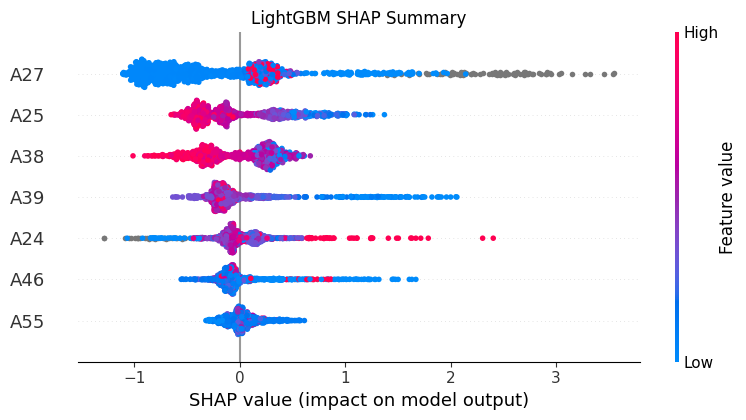

In [73]:
# SHAP 요약 그래프
shap.summary_plot(
    shap_values,
    X_valid[final_features],
    feature_names=final_features,
    show=False
)

plt.title(
    "LightGBM SHAP Summary"
)
plt.tight_layout()
plt.show()

SHAP 결과는 로지스틱과 대체로 일치하지만 일부 변수는 비선형 관계를 보임.

- A27: SHAP 중요도 1위. 값–SHAP 상관계수는 +0.427
  - 단순히 값이 클수록 위험하다는 뜻은 아님.
  - 앞의 구간표에서 음수와 결측 구간은 위험하고, 중간 구간은 매우 안전하며, 큰 양수 구간에서는 위험이 다시 조금 증가.
  - 따라서 U자형에 가까운 비선형 관계로 해석.
- A25: 상관계수 -0.894
  - 자기자본 관련 비율이 높을수록 부도예측을 강하게 낮춤.
- A38: 상관계수 -0.835
  - 상시자본 비율이 높을수록 부도예측을 낮춤.
- A39: 상관계수 -0.440
  - 매출이익률이 높을수록 부도예측을 낮추는 경향.
- A46: 상관계수 -0.354
  - 유동성 비율이 높을수록 부도예측을 낮춤. 점수카드 방향과 일치.
- A24, A55: 0에 가까움
  - 단순한 증가·감소보다 구간별 비선형 관계가 강함.

- LightGBM의 분할 횟수 중요도에서는 A24가 1위였지만, 평균 절대 SHAP에서는 A27이 1위. 이는 “자주 분할에 사용된 변수”와 “예측값을 크게 변화시킨 변수”가 다를 수 있음을 시사.


> SHAP 분석에서 A25, A38, A39, A46은 값이 높을수록 부도예측을 낮추는 방향으로 나타나 로지스틱 스코어카드와 대체로 일치했다. 반면 A27, A24, A55는 단순 단조관계보다 구간별 비선형성이 확인됐다. 특히 A27은 평균 절대 SHAP가 가장 컸지만 값–SHAP 관계가 단조적이지 않아, 변수 중요도와 영향 방향을 구분해 해석했다.

In [74]:
# year=1~4는 달력 연도가 아니라 각각 5년·4년·3년·2년 후 부도를 예측하는 자료
# 따라서 이것을 “시간 안정성 검증”이라고 부르지 않고 예측기간 변화에 대한 외부 적용 실험

# =========================================================
# 15. Cross-horizon transportability and score PSI
# =========================================================

_, psi_edges = pd.qcut(
    pd.Series(train_score),
    q=10,
    retbins=True,
    duplicates="drop"
)

psi_edges[0] = -np.inf
psi_edges[-1] = np.inf

In [77]:
def calculate_psi(
    reference_values,
    comparison_values,
    bins,
    epsilon=1e-6
):
    reference_count, _ = np.histogram(
        reference_values,
        bins=bins
    )

    comparison_count, _ = np.histogram(
        comparison_values,
        bins=bins
    )

    reference_ratio = (
        reference_count /
        reference_count.sum()
    )

    comparison_ratio = (
        comparison_count /
        comparison_count.sum()
    )

    reference_ratio = np.maximum(
        reference_ratio,
        epsilon
    )

    comparison_ratio = np.maximum(
        comparison_ratio,
        epsilon
    )

    return np.sum(
        (comparison_ratio - reference_ratio)
        * np.log(
            comparison_ratio /
            reference_ratio
        )
    )

In [78]:
# 다른 예측기간에 두 모델 적용

cross_horizon_rows = []
score_psi_rows = []

for year_value in [1, 2, 3, 4]:
    horizon_data = data.loc[
        data["year"] == year_value
    ].copy()

    X_horizon = horizon_data[
        feature_cols
    ]

    y_horizon = horizon_data[
        "class"
    ]

    # year=5 훈련 표본에서 정한 구간을 그대로 적용
    X_horizon_woe = transform_to_woe(
        X_horizon,
        final_features,
        binning_models
    )

    scorecard_metrics = calculate_metrics(
        "WOE logistic",
        f"year={year_value}",
        final_model,
        X_horizon_woe[final_features],
        y_horizon
    )

    scorecard_metrics["forecast_years"] = (
        6 - year_value
    )
    scorecard_metrics["n"] = len(y_horizon)
    scorecard_metrics["bad_rate"] = (
        y_horizon.mean()
    )

    cross_horizon_rows.append(
        scorecard_metrics
    )

    lightgbm_metrics = calculate_metrics(
        "LightGBM",
        f"year={year_value}",
        lightgbm_model,
        X_horizon[final_features],
        y_horizon
    )

    lightgbm_metrics["forecast_years"] = (
        6 - year_value
    )
    lightgbm_metrics["n"] = len(y_horizon)
    lightgbm_metrics["bad_rate"] = (
        y_horizon.mean()
    )

    cross_horizon_rows.append(
        lightgbm_metrics
    )

    horizon_probability = (
        final_model.predict_proba(
            X_horizon_woe[final_features]
        )[:, 1]
    )

    horizon_score = probability_to_score(
        horizon_probability
    )

    score_psi_rows.append({
        "year": year_value,
        "forecast_years": 6 - year_value,
        "n": len(y_horizon),
        "bad_rate": y_horizon.mean(),
        "score_psi_vs_year5_train": calculate_psi(
            train_score,
            horizon_score,
            psi_edges
        )
    })

In [79]:
# 결과

cross_horizon_table = pd.DataFrame(
    cross_horizon_rows
)

score_psi_table = pd.DataFrame(
    score_psi_rows
)

print("\n예측기간별 모델 성능:")
print(
    cross_horizon_table[
        [
            "model",
            "sample",
            "forecast_years",
            "n",
            "bad_rate",
            "roc_auc",
            "pr_auc",
            "ks",
            "brier",
            "log_loss"
        ]
    ]
)

print("\n예측기간별 점수분포 PSI:")
print(score_psi_table)


예측기간별 모델 성능:
          model  sample  forecast_years      n  bad_rate   roc_auc    pr_auc  \
0  WOE logistic  year=1               5   7027  0.038566  0.808816  0.120880   
1      LightGBM  year=1               5   7027  0.038566  0.883742  0.388464   
2  WOE logistic  year=2               4  10173  0.039320  0.756907  0.091457   
3      LightGBM  year=2               4  10173  0.039320  0.832995  0.235764   
4  WOE logistic  year=3               3  10503  0.047129  0.763376  0.116402   
5      LightGBM  year=3               3  10503  0.047129  0.831615  0.278085   
6  WOE logistic  year=4               2   9792  0.052594  0.793439  0.149759   
7      LightGBM  year=4               2   9792  0.052594  0.847547  0.329136   

         ks     brier  log_loss  
0  0.496520  0.039172  0.149820  
1  0.611225  0.030623  0.117934  
2  0.411406  0.048447  0.177451  
3  0.513107  0.041067  0.151251  
4  0.420772  0.055342  0.198103  
5  0.505052  0.045786  0.167290  
6  0.462245  0.057469  0.20

- 모든 PSI가 0.04 미만이므로 점수의 주변분포 자체는 크게 이동하지 않았습니다. 하지만 1년 예측 테스트 AUC 약 0.893보다 장기 예측자료의 로지스틱 AUC는 0.757~0.809로 낮아졌습니다.

> 입력에서 만들어진 점수분포는 비슷하지만, 그 점수와 실제 부도 사이의 관계는 예측기간에 따라 달라졌다.

- PSI: 점수분포 \(P(S)\)가 달라졌는가?
- AUC: 점수와 부도 \(Y\)의 순위 관계가 유지되는가?

낮은 PSI만 보고 모형이 안정적이라고 결론 내리면 안 된다는 것을 실제 결과로 보여줍니다.

> 1년 예측모형을 2-5년 예측기간 자료에 적용한 결과 점수 PSI는 모두 0.04 미만으로 분포 이동은 작았다. 그러나 로지스틱 AUC는 0.757~0.809로 1년 테스트 AUC 0.893보다 낮아졌다. 이는 점수의 주변분포가 유사하더라도 점수와 부도 사이의 조건부 관계는 유지되지 않을 수 있음을 보여준다. 따라서 PSI만으로 모형 안정성을 판단하지 않고 예측기간별 판별력을 함께 확인했다. 다만 서로 다른 기간 자료에 동일 기업이 포함됐는지 확인할 ID가 없으므로, 이를 완전히 독립적인 외부검증이라고 부르지는 않습니다.

In [80]:
# =========================================================
# 16. Export tables and figures
# =========================================================

import os

os.makedirs(
    "results",
    exist_ok=True
)

In [81]:
# 최종 표 저장

selected_summary.to_csv(
    "results/selected_variables.csv",
    index=False,
    encoding="utf-8-sig"
)

reduced_coefficient_table.to_csv(
    "results/logistic_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

final_metric_table.to_csv(
    "results/logistic_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

model_performance_comparison.to_csv(
    "results/model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

validation_grade_summary.to_csv(
    "results/validation_grade_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

test_grade_summary.to_csv(
    "results/test_grade_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

scorecard_table.to_csv(
    "results/scorecard_points.csv",
    index=False,
    encoding="utf-8-sig"
)

shap_direction_table.to_csv(
    "results/shap_interpretation.csv",
    index=False,
    encoding="utf-8-sig"
)

cross_horizon_table.to_csv(
    "results/cross_horizon_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

score_psi_table.to_csv(
    "results/cross_horizon_psi.csv",
    index=False,
    encoding="utf-8-sig"
)

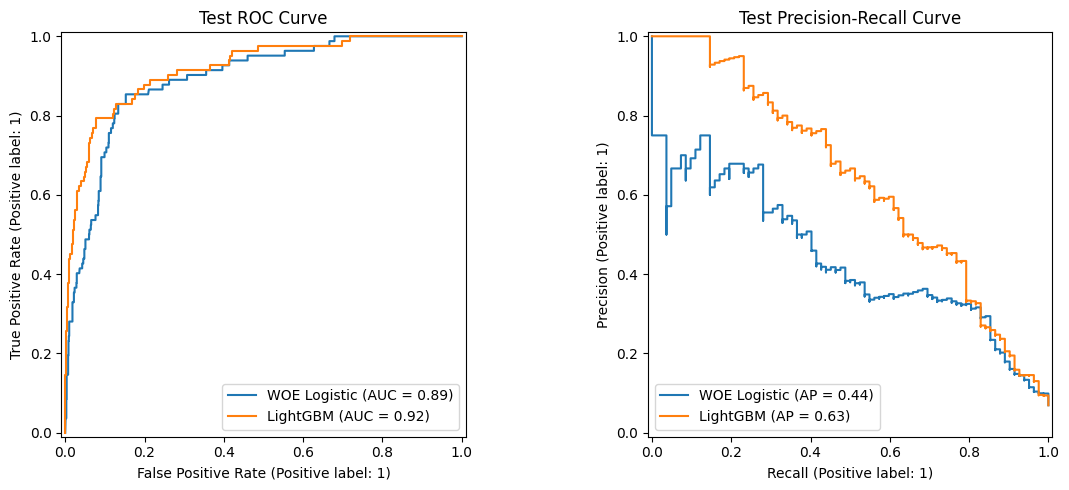

In [82]:
# 테스트 ROC,PR 곡선

from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay
)

lightgbm_test_probability = (
    lightgbm_model.predict_proba(
        X_test[final_features]
    )[:, 1]
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    name="WOE Logistic",
    ax=axes[0]
)

RocCurveDisplay.from_predictions(
    y_test,
    lightgbm_test_probability,
    name="LightGBM",
    ax=axes[0]
)

axes[0].set_title("Test ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probability,
    name="WOE Logistic",
    ax=axes[1]
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    lightgbm_test_probability,
    name="LightGBM",
    ax=axes[1]
)

axes[1].set_title(
    "Test Precision-Recall Curve"
)

plt.tight_layout()

plt.savefig(
    "results/test_roc_pr_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

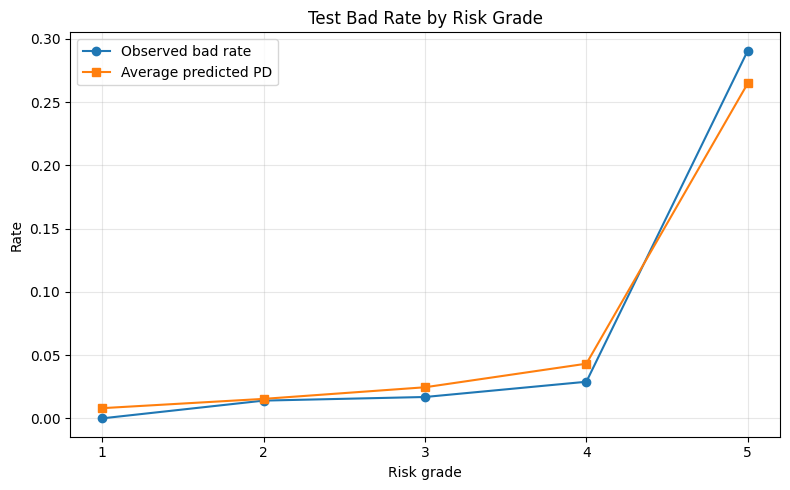

In [83]:
# 등급별 실제 부도율과 예측확률

fig, ax = plt.subplots(
    figsize=(8, 5)
)

grades = (
    test_grade_summary["grade"]
    .astype(int)
)

ax.plot(
    grades,
    test_grade_summary["bad_rate"],
    marker="o",
    label="Observed bad rate"
)

ax.plot(
    grades,
    test_grade_summary["average_pd"],
    marker="s",
    label="Average predicted PD"
)

ax.set_xlabel("Risk grade")
ax.set_ylabel("Rate")
ax.set_title(
    "Test Bad Rate by Risk Grade"
)

ax.set_xticks(grades)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "results/test_grade_bad_rate.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


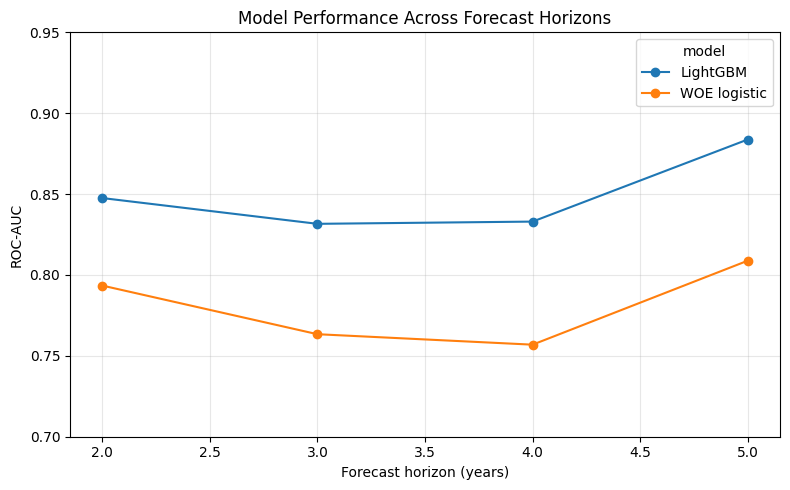

In [84]:
# 예측 기간별 AUC

auc_plot_data = (
    cross_horizon_table
    .pivot(
        index="forecast_years",
        columns="model",
        values="roc_auc"
    )
    .sort_index()
)

auc_plot_data.plot(
    marker="o",
    figsize=(8, 5)
)

plt.xlabel("Forecast horizon (years)")
plt.ylabel("ROC-AUC")
plt.title(
    "Model Performance Across Forecast Horizons"
)
plt.ylim(0.70, 0.95)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "results/cross_horizon_auc.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

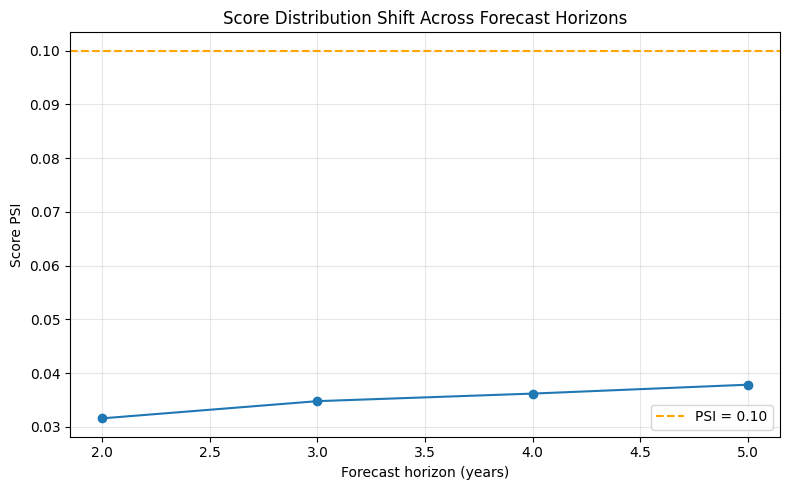

In [85]:
#PSI 그래프

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    score_psi_table["forecast_years"],
    score_psi_table[
        "score_psi_vs_year5_train"
    ],
    marker="o"
)

plt.axhline(
    0.10,
    color="orange",
    linestyle="--",
    label="PSI = 0.10"
)

plt.xlabel("Forecast horizon (years)")
plt.ylabel("Score PSI")
plt.title(
    "Score Distribution Shift Across Forecast Horizons"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "results/cross_horizon_psi.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [86]:
print("저장된 결과 파일:")
print(
    sorted(
        os.listdir("results")
    )
)

저장된 결과 파일:
['cross_horizon_auc.png', 'cross_horizon_performance.csv', 'cross_horizon_psi.csv', 'cross_horizon_psi.png', 'logistic_coefficients.csv', 'logistic_performance.csv', 'model_comparison.csv', 'scorecard_points.csv', 'selected_variables.csv', 'shap_interpretation.csv', 'test_grade_bad_rate.png', 'test_grade_summary.csv', 'test_roc_pr_curves.png', 'validation_grade_summary.csv']
